In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('data/dog_adoption_master.csv')
df.head()

,adoption_id,age_years,size,weight_kg,breed_group,intake_type,days_in_shelter,previously_returned,medical_needs,neutered,...,adopter_activity_level,visits_before_adoption,met_resident_pets,adoption_counseling,expectation_score,energy_mismatch,size_home_mismatch,return_reason,days_to_return,returned
0,ADP000000,2.6,small,7.2,mixed,stray,51,0,none,1,...,2.6,1,0,0,7.3,1.4,0,kept,NaN,0
1,ADP000001,5.4,large,27.9,sporting,stray,38,1,none,1,...,3.8,1,0,0,6.2,4.2,0,kept,NaN,0
2,ADP000002,3.5,medium,15.4,mixed,owner_surrender,14,0,none,1,...,1.1,1,0,0,8.1,3.5,0,kept,NaN,0
3,ADP000003,7.3,medium,23.2,working,stray,9,0,none,1,...,7.8,3,0,1,10.0,0.8,0,unmet_expectations,4.5,1
4,ADP000004,0.7,medium,16.2,mixed,stray,35,1,minor,1,...,3.6,1,0,0,7.9,6.4,0,aggression,12.9,1


In [2]:
print(f"Total de cães/adoções registradas: {df.shape[0]:,}".replace(',', '.'))
print(f"Total de características analisadas (variáveis): {df.shape[1]}")

Total de cães/adoções registradas: 42.000
Total de características analisadas (variáveis): 32


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 42000 entries, 0 to 41999
Data columns (total 32 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   adoption_id             42000 non-null  str    
 1   age_years               42000 non-null  float64
 2   size                    42000 non-null  str    
 3   weight_kg               42000 non-null  float64
 4   breed_group             42000 non-null  str    
 5   intake_type             42000 non-null  str    
 6   days_in_shelter         42000 non-null  int64  
 7   previously_returned     42000 non-null  int64  
 8   medical_needs           42000 non-null  str    
 9   neutered                42000 non-null  int64  
 10  aggression_score        42000 non-null  float64
 11  anxiety_separation      42000 non-null  float64
 12  reactivity_to_dogs      42000 non-null  float64
 13  energy_level            42000 non-null  float64
 14  training_level          42000 non-null  float64
 

In [4]:
nulos = df.isnull().sum()
percentual_nulos = (df.isnull().mean() * 100).round(2)

tabela_nulos = pd.DataFrame({
    'Valores Nulos': nulos,
    'Percentual (%)': percentual_nulos
})
tabela_nulos[tabela_nulos['Valores Nulos'] > 0]

,Valores Nulos,Percentual (%)
days_to_return,35703,85.01


In [5]:
duplicados = df.duplicated().sum()
print(f"Adoções duplicadas identificadas: {duplicados}")

Adoções duplicadas identificadas: 0


In [6]:
print("Idades negativas (< 0 anos):", (df['age_years'] < 0).sum())
print("Pesos inválidos (<= 0 kg):", (df['weight_kg'] <= 0).sum())
print("Horas sozinho por dia > 24h:", (df['hours_alone_per_day'] > 24).sum())
print("Notas de agressividade fora de [0 a 10]:", ((df['aggression_score'] < 0) | (df['aggression_score'] > 10)).sum())

Idades negativas (< 0 anos): 0
Pesos inválidos (<= 0 kg): 0
Horas sozinho por dia > 24h: 0
Notas de agressividade fora de [0 a 10]: 0


In [7]:
df[['age_years', 'weight_kg', 'days_in_shelter', 'hours_alone_per_day']].describe().round(2)

,age_years,weight_kg,days_in_shelter,hours_alone_per_day
count,42000.00,42000.00,42000.00,42000.00
mean,3.80,20.27,35.77,6.00
std,2.67,12.16,27.37,2.91
min,0.20,2.00,1.00,0.00
25%,1.80,8.90,16.00,4.00
50%,3.20,18.80,29.00,6.00
75%,5.20,28.70,49.00,8.00
max,16.00,70.60,350.00,14.00


In [8]:
df_limpo = df.copy()

df_limpo['days_to_return'] = df_limpo['days_to_return'].fillna(0)

df_devolvidos = df.dropna(subset=['days_to_return']).copy()

print(f"Estratégia 1 — Base geral tratada (nulos restantes em days_to_return): {df_limpo['days_to_return'].isnull().sum()}")
print(f"Estratégia 2 — Subconjunto de devoluções para análise (cães): {len(df_devolvidos):,}".replace(',', '.'))

Estratégia 1 — Base geral tratada (nulos restantes em days_to_return): 0
Estratégia 2 — Subconjunto de devoluções para análise (cães): 6.297


In [9]:
linhas_antes = len(df_limpo)
df_limpo = df_limpo.drop_duplicates().reset_index(drop=True)
linhas_depois = len(df_limpo)

print(f"Total de registros: {linhas_depois} (nenhum registro foi duplicado)")

Total de registros: 42000 (nenhum registro foi duplicado)


In [10]:
Q1 = df_limpo['days_in_shelter'].quantile(0.25)
Q3 = df_limpo['days_in_shelter'].quantile(0.75)
IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

df_limpo['days_in_shelter'] = df_limpo['days_in_shelter'].clip(lower=limite_inferior, upper=limite_superior)

Q1_w = df_limpo['weight_kg'].quantile(0.25)
Q3_w = df_limpo['weight_kg'].quantile(0.75)
IQR_w = Q3_w - Q1_w
lim_inf_w = max(0, Q1_w - 1.5 * IQR_w)
lim_sup_w = Q3_w + 1.5 * IQR_w
df_limpo['weight_kg'] = df_limpo['weight_kg'].clip(lower=lim_inf_w, upper=lim_sup_w)

print("Tratamento de outliers concluído com sucesso via Clipping, preservando todos os 42.000 cães!")

Tratamento de outliers concluído com sucesso via Clipping, preservando todos os 42.000 cães!


In [11]:
df_limpo.to_csv('data/dog_adoption_master_limpo.csv', index=False)
print(f"Base final salva: {df_limpo.shape[0]:,} registros e {df_limpo.shape[1]} colunas.".replace(',', '.'))

Base final salva: 42.000 registros e 32 colunas.


In [12]:
colunas_estatisticas = ['age_years', 'weight_kg', 'days_in_shelter', 'hours_alone_per_day', 'aggression_score', 'expectation_score']

tabela_descritiva = pd.DataFrame({
    'Média': df_limpo[colunas_estatisticas].mean(),
    'Mediana': df_limpo[colunas_estatisticas].median(),
    'Moda': [df_limpo[c].mode().iloc[0] for c in colunas_estatisticas],
    'Desvio Padrão': df_limpo[colunas_estatisticas].std(),
    'Mínimo': df_limpo[colunas_estatisticas].min(),
    'Máximo': df_limpo[colunas_estatisticas].max()
}).round(2)

tabela_descritiva

,Média,Mediana,Moda,Desvio Padrão,Mínimo,Máximo
age_years,3.80,3.2,1.7,2.67,0.2,16.0
weight_kg,20.26,18.8,6.6,12.14,2.0,58.4
days_in_shelter,34.95,29.0,98.5,24.63,1.0,98.5
hours_alone_per_day,6.00,6.0,0.0,2.91,0.0,14.0
aggression_score,2.52,2.4,0.0,1.85,0.0,10.0
expectation_score,6.61,6.6,10.0,1.86,0.0,10.0


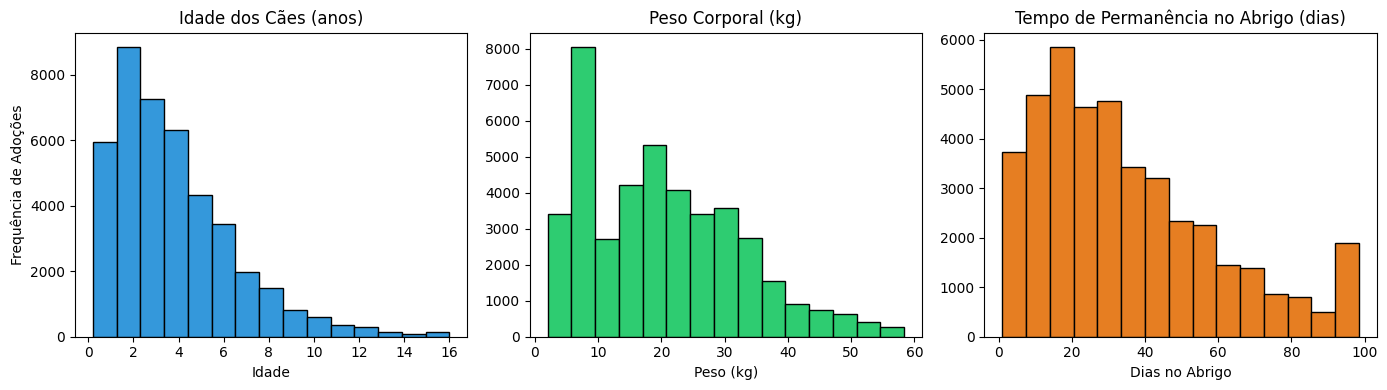

In [13]:
plt.figure(figsize=(14, 4))

plt.subplot(1, 3, 1)
plt.hist(df_limpo['age_years'], bins=15, color='#3498db', edgecolor='black')
plt.title('Idade dos Cães (anos)')
plt.xlabel('Idade')
plt.ylabel('Frequência de Adoções')

plt.subplot(1, 3, 2)
plt.hist(df_limpo['weight_kg'], bins=15, color='#2ecc71', edgecolor='black')
plt.title('Peso Corporal (kg)')
plt.xlabel('Peso (kg)')

plt.subplot(1, 3, 3)
plt.hist(df_limpo['days_in_shelter'], bins=15, color='#e67e22', edgecolor='black')
plt.title('Tempo de Permanência no Abrigo (dias)')
plt.xlabel('Dias no Abrigo')

plt.tight_layout()
plt.show()

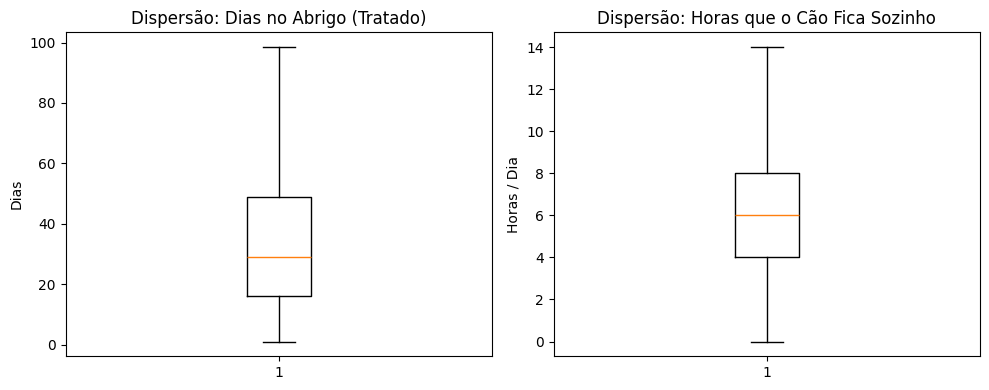

In [14]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.boxplot(df_limpo['days_in_shelter'])
plt.title('Dispersão: Dias no Abrigo (Tratado)')
plt.ylabel('Dias')

plt.subplot(1, 2, 2)
plt.boxplot(df_limpo['hours_alone_per_day'])
plt.title('Dispersão: Horas que o Cão Fica Sozinho')
plt.ylabel('Horas / Dia')

plt.tight_layout()
plt.show()

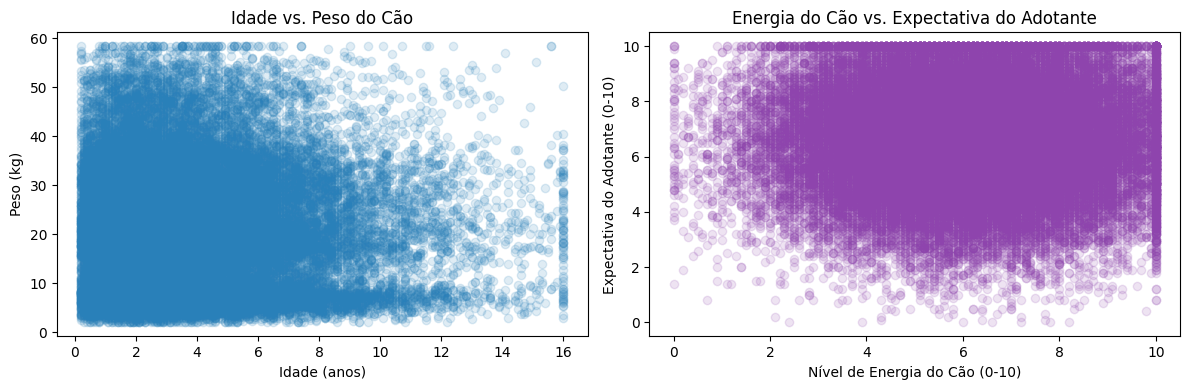

In [15]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.scatter(df_limpo['age_years'], df_limpo['weight_kg'], alpha=0.15, color='#2980b9')
plt.title('Idade vs. Peso do Cão')
plt.xlabel('Idade (anos)')
plt.ylabel('Peso (kg)')

plt.subplot(1, 2, 2)
plt.scatter(df_limpo['energy_level'], df_limpo['expectation_score'], alpha=0.15, color='#8e44ad')
plt.title('Energia do Cão vs. Expectativa do Adotante')
plt.xlabel('Nível de Energia do Cão (0-10)')
plt.ylabel('Expectativa do Adotante (0-10)')

plt.tight_layout()
plt.show()

In [16]:
amostra_simples = df_limpo.sample(frac=0.10, random_state=42)

amostra_estratificada = df_limpo.groupby('size', group_keys=False).sample(frac=0.10, random_state=42)

prop_populacao = df_limpo['size'].value_counts(normalize=True).round(3) * 100
prop_simples = amostra_simples['size'].value_counts(normalize=True).round(3) * 100
prop_estratificada = amostra_estratificada['size'].value_counts(normalize=True).round(3) * 100

comparacao_portes = pd.DataFrame({
    'População Geral (%)': prop_populacao,
    'Amostra Aleatória Simples (%)': prop_simples,
    'Amostra Estratificada (%)': prop_estratificada
})

comparacao_portes

,População Geral (%),Amostra Aleatória Simples (%),Amostra Estratificada (%)
size,,,
medium,34.2,34.3,34.2
small,29.8,28.8,29.8
large,27.9,28.7,27.9
xlarge,8.1,8.2,8.1


In [17]:
comparacao_medias = pd.DataFrame({
    'Variável': ['Idade Média (anos)', 'Peso Médio (kg)', 'Média Dias no Abrigo'],
    'População Geral': [df_limpo['age_years'].mean(), df_limpo['weight_kg'].mean(), df_limpo['days_in_shelter'].mean()],
    'Amostra Simples': [amostra_simples['age_years'].mean(), amostra_simples['weight_kg'].mean(), amostra_simples['days_in_shelter'].mean()],
    'Amostra Estratificada': [amostra_estratificada['age_years'].mean(), amostra_estratificada['weight_kg'].mean(), amostra_estratificada['days_in_shelter'].mean()]
}).round(2)

comparacao_medias

,Variável,População Geral,Amostra Simples,Amostra Estratificada
0,Idade Média (anos),3.80,3.78,3.83
1,Peso Médio (kg),20.26,20.40,20.32
2,Média Dias no Abrigo,34.95,35.02,34.90


,Média (Original),Média (Tratada),Desvio Padrão (Original),Desvio Padrão (Tratado),Variação Desvio (%)
days_in_shelter,35.77,34.95,27.37,24.63,-10.00
weight_kg,20.27,20.26,12.16,12.14,-0.19
age_years,3.80,3.80,2.67,2.67,0.00
hours_alone_per_day,6.00,6.00,2.91,2.91,0.00


<Figure size 900x400 with 0 Axes>

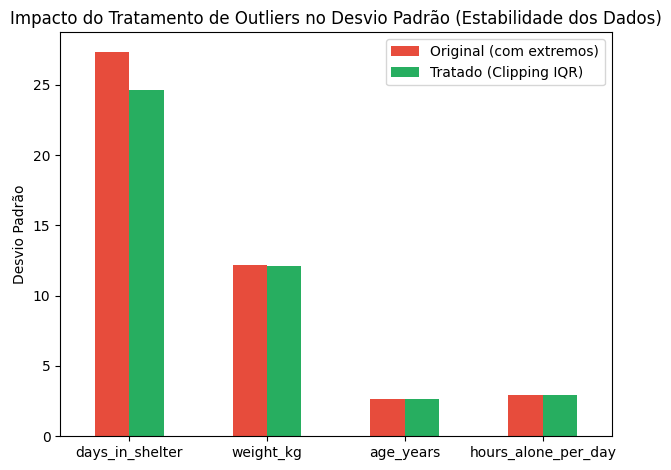

In [18]:
variaveis_comp = ['days_in_shelter', 'weight_kg', 'age_years', 'hours_alone_per_day']

comparacao_antes_depois = pd.DataFrame({
    'Média (Original)': df[variaveis_comp].mean(),
    'Média (Tratada)': df_limpo[variaveis_comp].mean(),
    'Desvio Padrão (Original)': df[variaveis_comp].std(),
    'Desvio Padrão (Tratado)': df_limpo[variaveis_comp].std(),
    'Variação Desvio (%)': ((df_limpo[variaveis_comp].std() - df[variaveis_comp].std()) / df[variaveis_comp].std() * 100).round(2)
}).round(2)

display(comparacao_antes_depois)

plt.figure(figsize=(9, 4))
comparacao_antes_depois[['Desvio Padrão (Original)', 'Desvio Padrão (Tratado)']].plot(kind='bar', color=['#e74c3c', '#27ae60'])
plt.title('Impacto do Tratamento de Outliers no Desvio Padrão (Estabilidade dos Dados)')
plt.ylabel('Desvio Padrão')
plt.xticks(rotation=0)
plt.legend(['Original (com extremos)', 'Tratado (Clipping IQR)'])
plt.tight_layout()
plt.show()